# Handling missing data, filled
This document (briefly) introduces the concept, categorization, and treatment of missing data.

## Classical categories of missing data
If we know how the missing data are generated, so-called missing data mechanisms, we can take into account why data are missing in data analysis. 

A particularly useful (and wide-known) framework for missingness categorizes missingness into the following three categories (Little and Rudin, 2019):

*Caveat... the category namings are... confusing*

**MCAR (missing completely at random):** how data are missing is independent with any aspect of the data

**MAR (missing at random):** how data are missing depends on **observed** quantities, so-called *predictors, or independent variables*
- e.g., a person with certain characteristics (known) may not answer certain questions on a survey, *imagine reporting salary for different socio-economic classes*
- e.g., for certain inputs, a simulation model may crash or produce nonsensical outputs

**MNAR (missing not at random):** how data are missing depends on the **unobserved** quantities
- e.g., a pollutant sensor can only detect particles that are $> 0.1\mu\mathrm{m}$  
- e.g., storm surges only occur in areas that get below the water level

Understanding the causes of missing data helps designing algorithms to handle missing data.  *However*, in reality, we often do not know the causes, or multiple causes exist in producing a data set.

**Cautionary note:** Where the data are missing matters, i.e., is a response value missing, is a predictor value missing, or do we not know what our analysis questions are yet?

## Treatment of missing data

**Starting with an example of "completing the data"**  

|                            |
|:--------------------------:|
|![gas-a](../img/gas-a.png)  |

|                            |Replace with the mean       |
|:--------------------------:|:--------------------------:|
|![gas-a](../img/gas-a.png)  |![gas-b](../img/gas-b.png)  |

|                            |Replace with the mean + noise|
|:--------------------------:|:--------------------------:|
|![gas-a](../img/gas-a.png)  |![gas-c](../img/gas-c.png)  |

|                            |Replace with the mean + noise + parameter uncertainty|
|:--------------------------:|:--------------------------:|
|![gas-a](../img/gas-a.png)  |![gas-d](../img/gas-d.png)  |

|                            |More information + replace with mean + noise|
|:--------------------------:|:--------------------------:|
|![gas-a](../img/gas-a.png)  |![gas-e](../img/gas-e.png)  |

|                            |Predictive mean matching|
|:--------------------------:|:--------------------------:|
|![gas-a](../img/gas-a.png)  |![gas-f](../img/gas-f.png)  |

**Example of missingness impacting analysis** from Daniel et al. (2012), reproducing Figure 4 in the paper:

|![mar-mnar](../img/mar-mnar.png)|
|:---:|
|Effect of missingness mechanism on data analysis.|


### General rules for treating missing data:  
- Under MCAR, focusing on complete cases or employing imputation methods tend to be sufficient.
- Under MAR, some methods are valid choices:
  - If the missingness is independent of the response *conditional* on the predictor, linear regression is still "valid".
  - Imputation methods tend to introduce biases, depending on the data analysis methods.
- Under MNAR, the missingness should be explicitly modeled.
  - e.g., censored observations in survival analysis.

## Imputation methods
We introduce a (limited) list of imputation methods in this section, using the `titanic` dataset as an example:

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.precision', 3)

titanic = sns.load_dataset('titanic', cache=True, data_home='dataset/')

### Identifying missingness
We have covered some basic ways how to identify missingness in the EDA module.  Here is one other option with the help of `missingno`.

<Axes: >

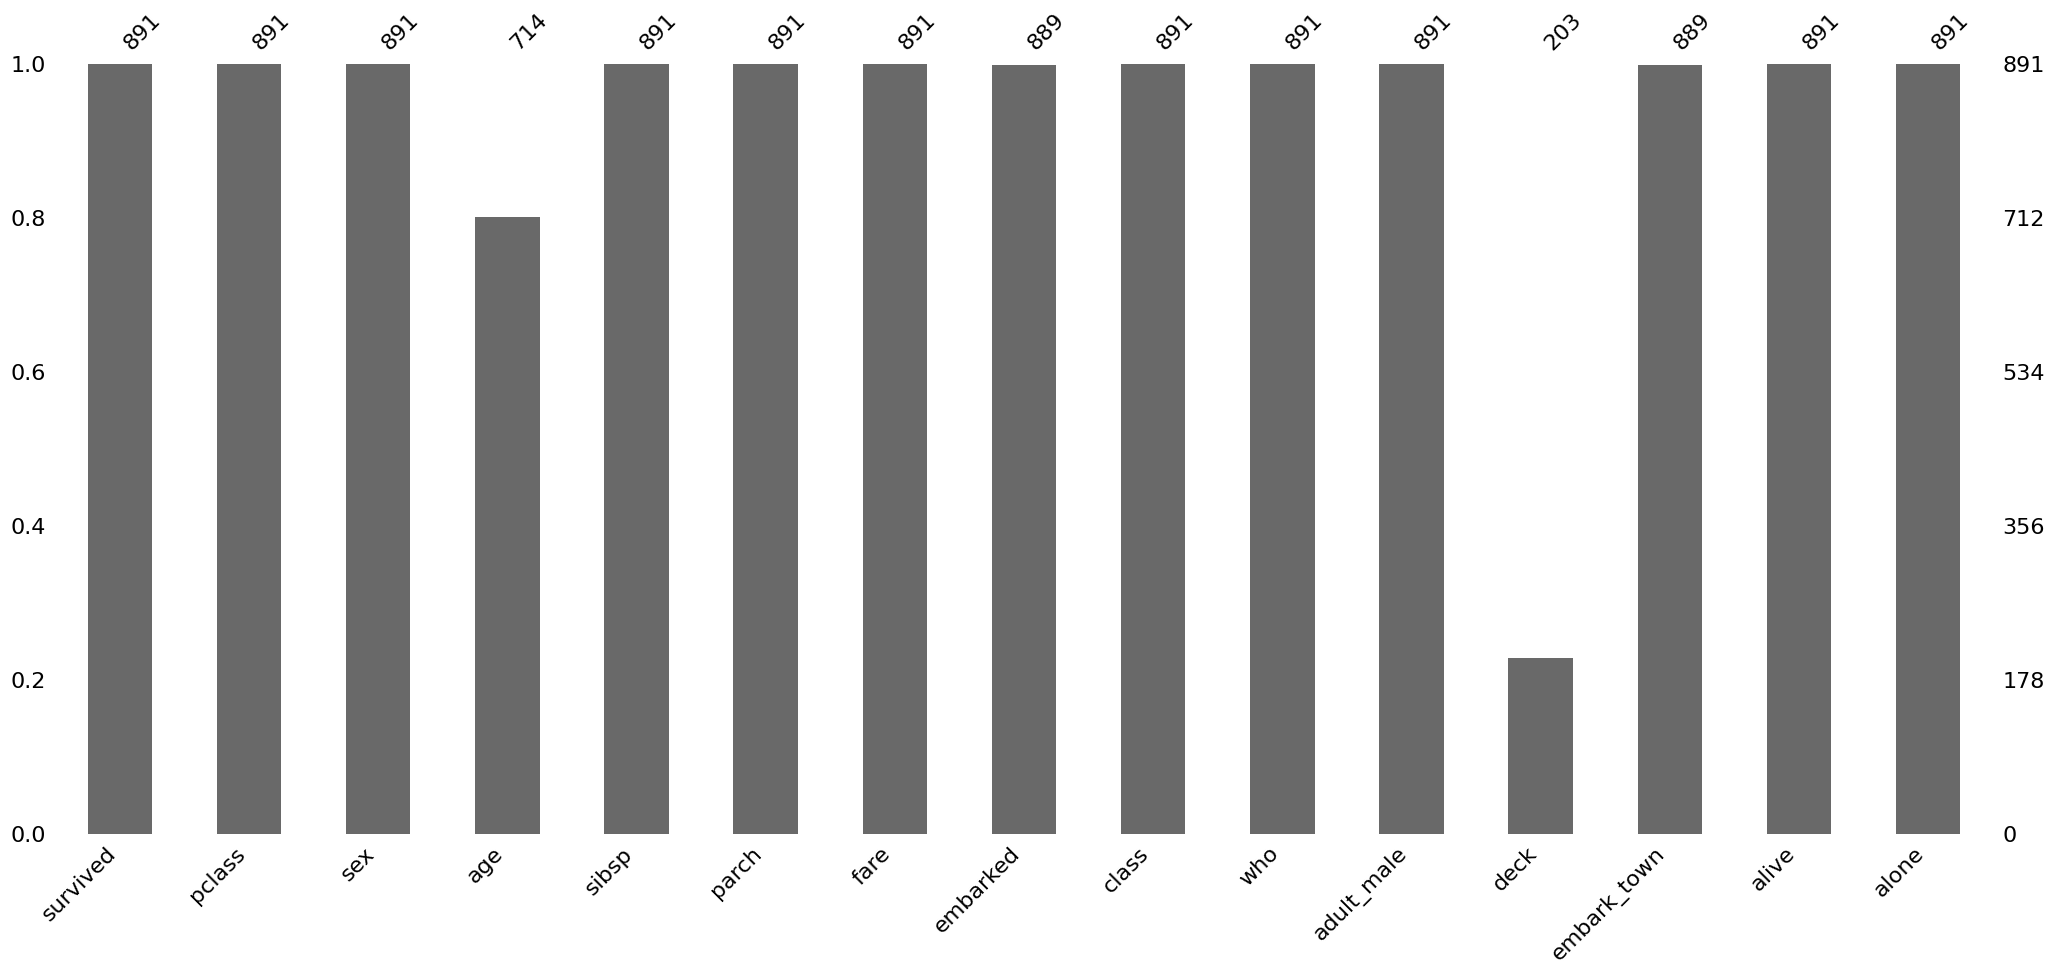

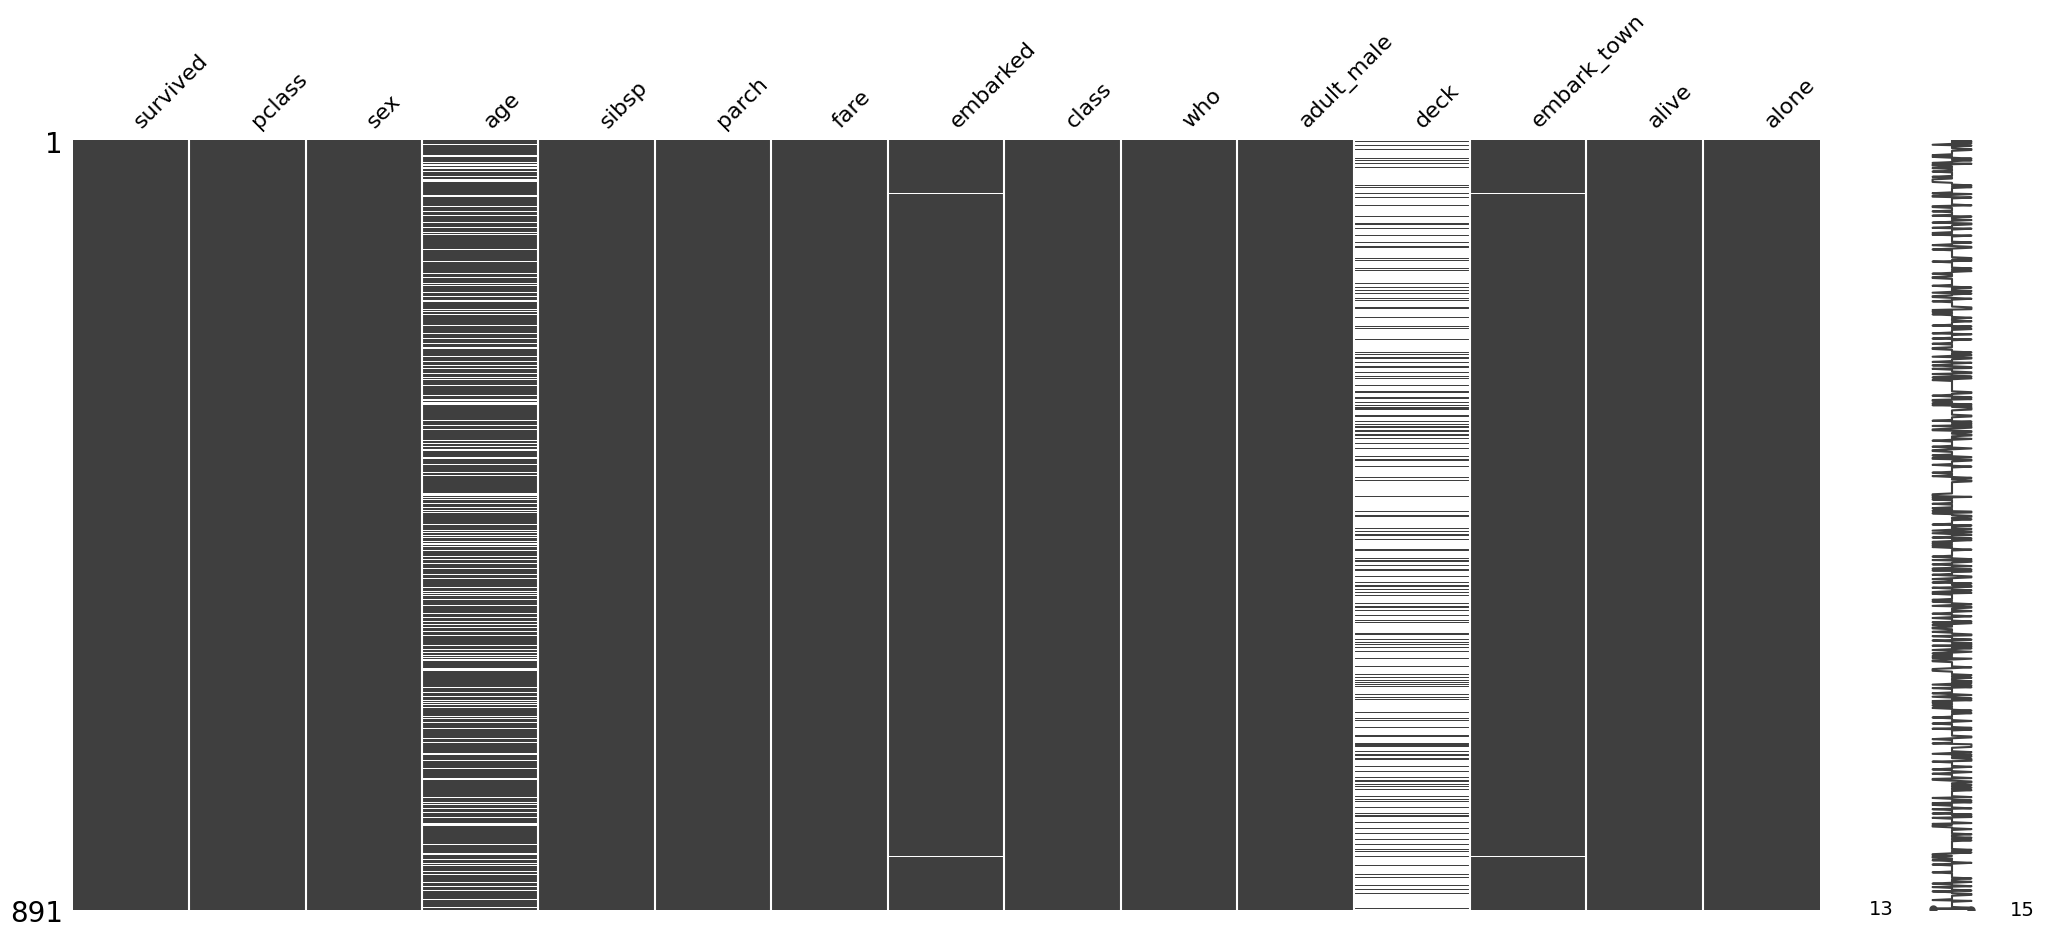

In [2]:
# !pip install missingno  
# in case you need to install the package
import missingno as msno

# visualization of available/missing data
msno.bar(titanic)
msno.matrix(titanic)

### Removing data
We have discussed that removing data is typically not ideal, but nothing stops us from doing that...

<Axes: >

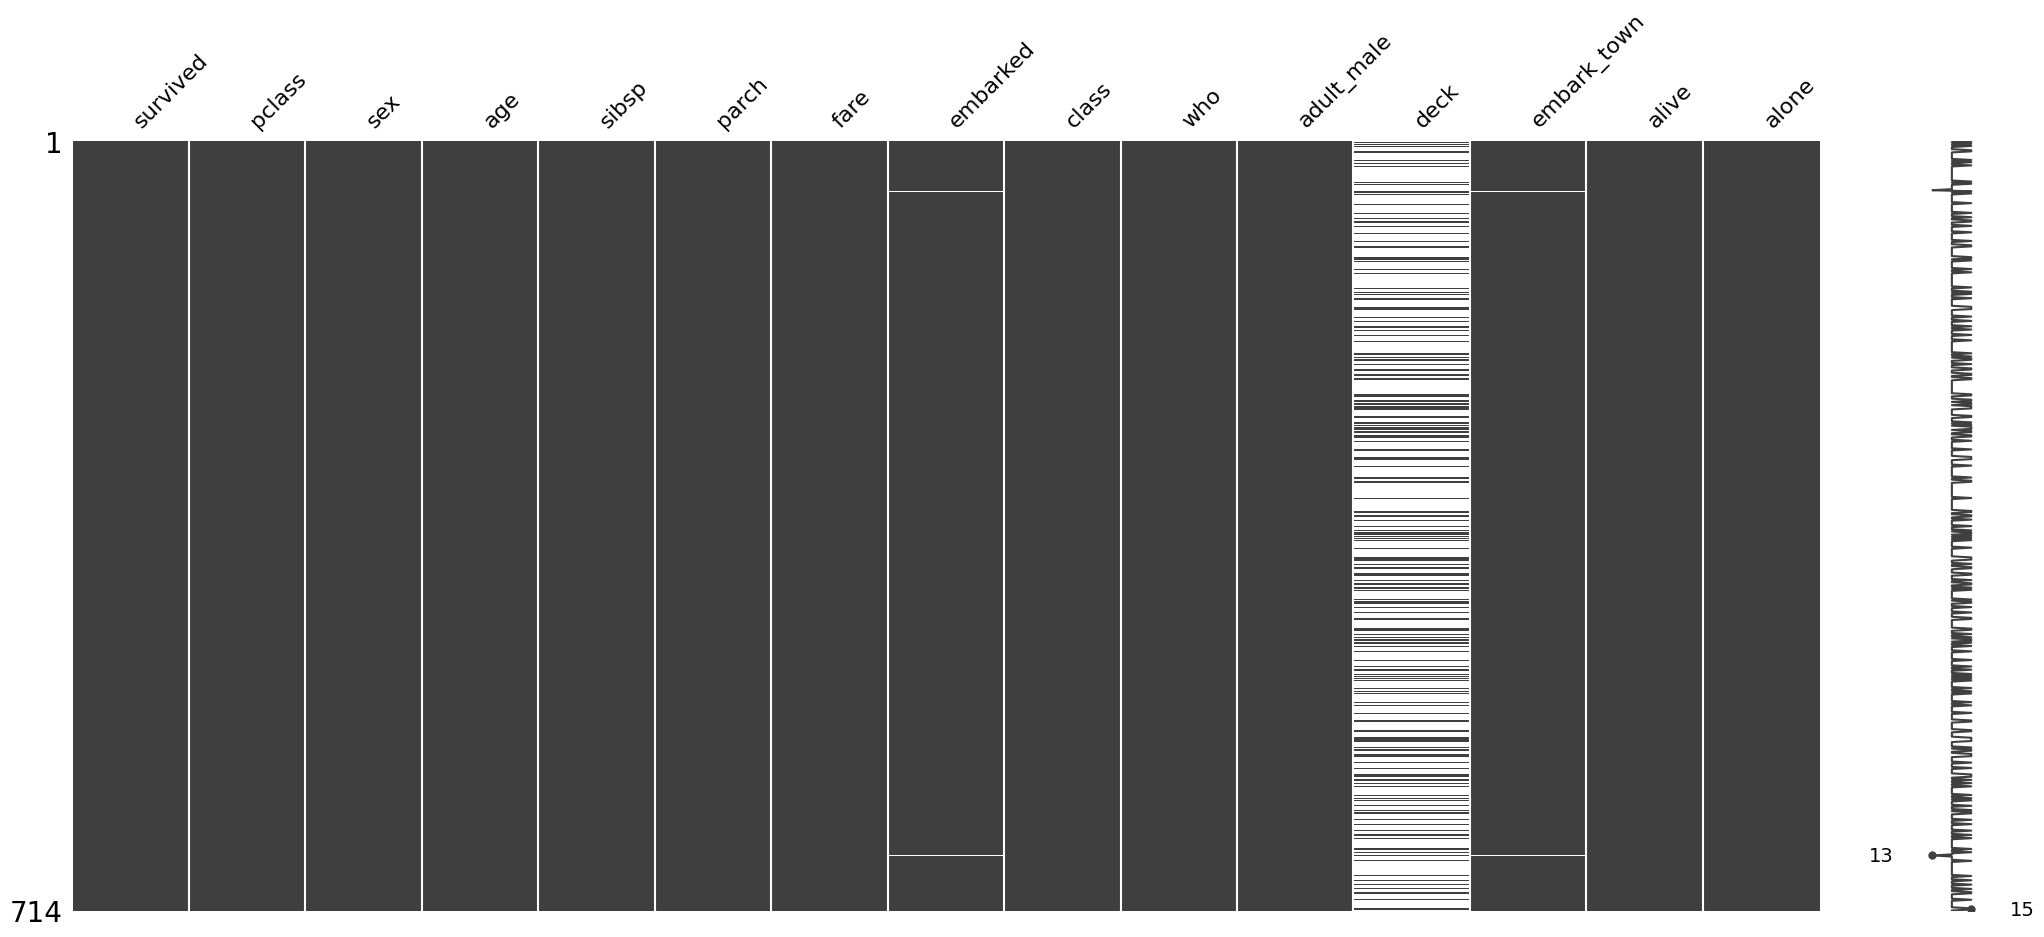

In [3]:
titanic_agecomp = titanic.dropna(subset='age', how='any')
msno.matrix(titanic_agecomp)

In [4]:
corr = titanic.select_dtypes('number').corr()
corr_agecomp = titanic_agecomp.select_dtypes('number').corr()

# changes in correlation matrix with / without age missingness
corr - corr_agecomp

,survived,pclass,age,sibsp,parch,fare
survived,0.000,0.021,0.0,-0.018,-0.012,-0.011
pclass,0.021,0.000,0.0,0.016,-0.007,0.005
age,0.000,0.000,0.0,0.000,0.000,0.000
sibsp,-0.018,0.016,0.0,0.000,0.031,0.021
parch,-0.012,-0.007,0.0,0.031,0.000,0.011
fare,-0.011,0.005,0.0,0.021,0.011,0.000


### Simple imputation with a constant

In [5]:
# !pip install scikit-learn
from sklearn.impute import SimpleImputer
constant_imputer = SimpleImputer(strategy='constant')  # 'median', 'most_frequent', 'constant'

<Axes: xlabel='age', ylabel='Count'>

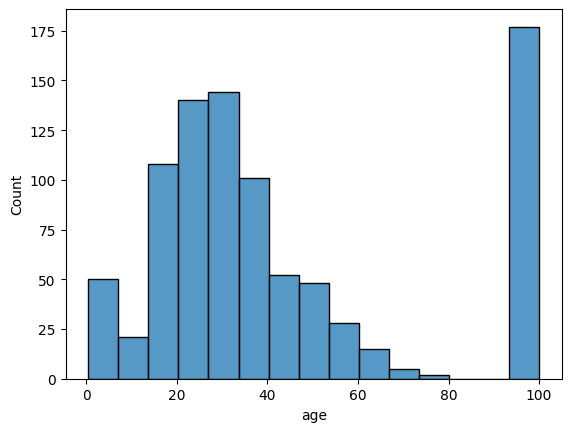

In [6]:
titanic_constant = titanic.copy()

# set constant
constant_imputer.fill_value = 100
titanic_constant['age'] = constant_imputer.fit_transform(titanic_constant[['age']])

sns.histplot(titanic_constant['age'])

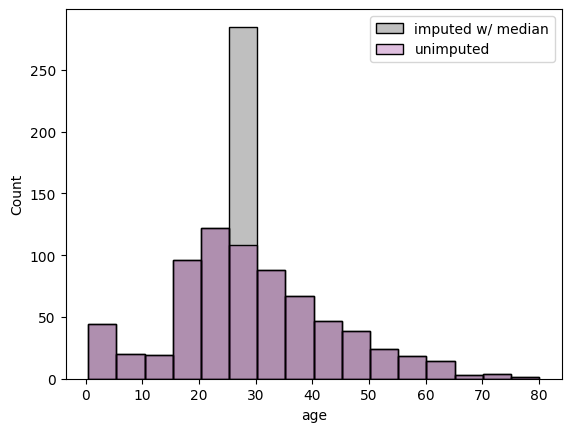

In [7]:
# example with median, admitting only numeric columns
median_imputer = SimpleImputer(strategy='median')
titanic_median = titanic.copy()
titanic_median['age'] = median_imputer.fit_transform(titanic_median[['age']])
# another option
# titanic_median['age'] = titanic_median['age'].fillna(titanic_median['age'].median())

fig, ax = plt.subplots(1, 1)
sns.histplot(titanic_median['age'], binwidth=5, alpha=0.25, color='k', label='imputed w/ median')
sns.histplot(titanic['age'], binwidth=5, alpha=0.25, color='purple', label='unimputed')
ax.legend()

### Multiple imputation
Multiple imputation is a technique to generate multiple realizations of imputation values, often modeled by a probability distribution.

One method is the multiple imputation by chained equations, or MICE. `miceforest` uses LightBGM as its training algorithm for MICE.

In [8]:
# !pip install --upgrade miceforest plotnine
import miceforest as mf

# miceforest requires a real matrix. 
# For illustrative purposes, we only use the numerical columns.

# set up a kernel to produce `num_datasets` imputed datasets
num_datasets = 4
kernel = mf.ImputationKernel(
  titanic.select_dtypes('number'),
  num_datasets=num_datasets,
  save_all_iterations_data=False,
  random_state=1
)

In [9]:
# run the MICE algorithm
kernel.mice(iterations=10)

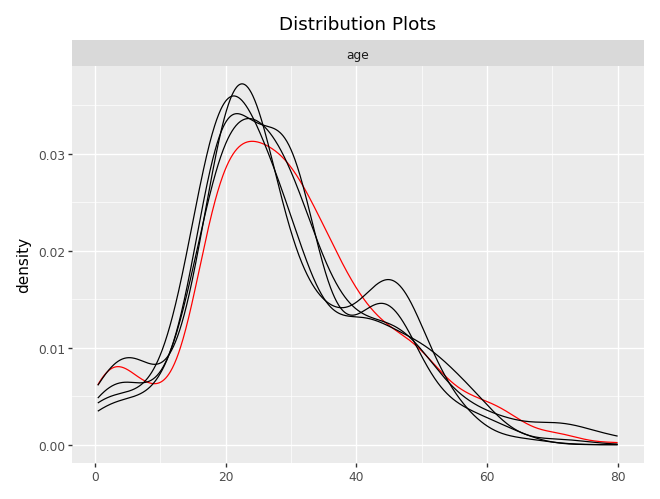

In [10]:
# plot imputed distributions
kernel.plot_imputed_distributions()

In [11]:
titanic_mf = kernel.complete_data
titanic_mf

<bound method ImputedData.complete_data of 
              Class: ImputationKernel
            Datasets: 4
          Iterations: 10
        Data Samples: 891
        Data Columns: 6
   Imputed Variables: 1
   Modeled Variables: 1
All Iterations Saved: False
        >

In [12]:
def plot_hist(kernel, completed_titanic, original_titanic, num_plot):
    num_datasets = kernel.num_datasets
    num_plot = min(num_datasets, num_plot)
    for k in range(num_plot):  # 1, 2, 3, num_datasets
        sns.histplot(completed_titanic(dataset=k)['age'], binwidth=5, stat='probability', color='k', label='imputed sample', alpha=0.3)
    
    sns.histplot(original_titanic['age'], binwidth=5, stat='probability', color='purple', label='unimputed', alpha=0.2)
    
    plt.title('{:d} realizations of imputed age'.format(num_plot))
    plt.legend()
    plt.tight_layout()
    plt.show()

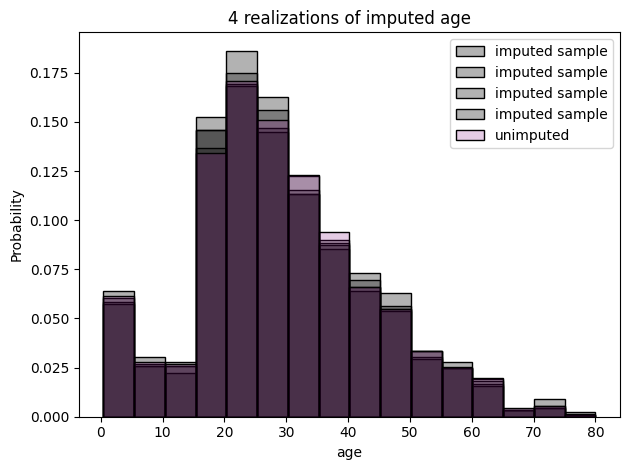

In [13]:
# retrieving each imputed dataset
import matplotlib.pyplot as plt

plot_hist(kernel=kernel, completed_titanic=titanic_mf, original_titanic=titanic, num_plot=4)

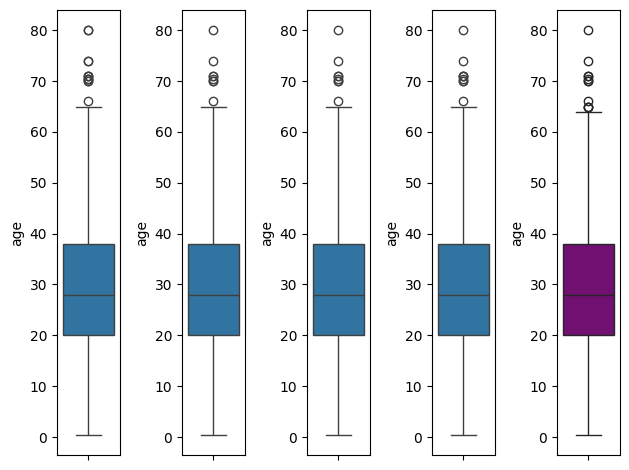

In [14]:
fig, ax = plt.subplots(ncols=5)

for k, axi in enumerate(ax.flatten()):
    if k < num_datasets:
        sns.boxplot(titanic_mf(dataset=k)['age'], ax=axi)
    else:
        sns.boxplot(titanic['age'], ax=axi, color='purple')

plt.tight_layout()
plt.show()

### Predictive mean matching

In [24]:
kernel_pmm = mf.ImputationKernel(
    data=titanic.select_dtypes('number'),
    num_datasets=50,
    mean_match_candidates=3,
    random_state=1,
    save_all_iterations_data=False
)

In [25]:
kernel_pmm.mice(iterations=10)

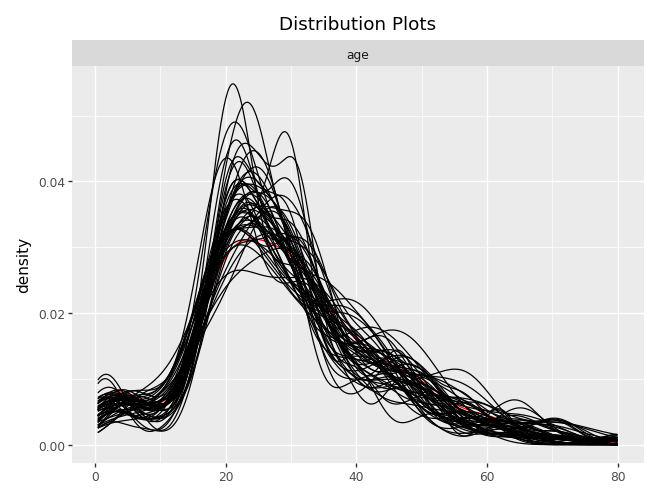

In [26]:
kernel_pmm.plot_imputed_distributions()

In [ ]:
kernel_pmm.tune_parameters()

In [ ]:
titanic_pmm = kernel_pmm.complete_data

In [ ]:
plot_hist(kernel=kernel, completed_titanic=titanic_pmm, original_titanic=titanic, num_plot=4)

### $k$ Nearest Neighbor

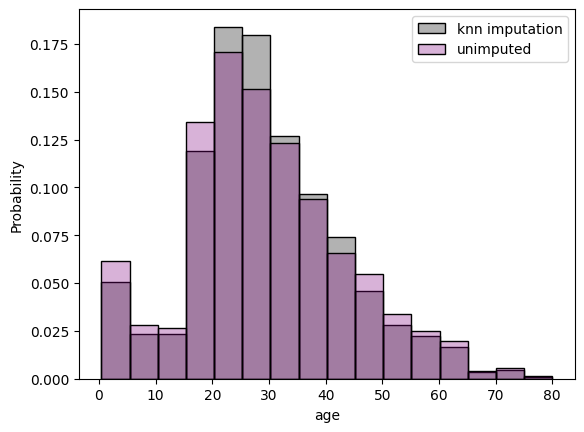

In [27]:
from sklearn.impute import KNNImputer
titanic_knn = titanic.select_dtypes('number').copy()

knn_imputer = KNNImputer(n_neighbors=3)
titanic_knn_impute = knn_imputer.fit_transform(titanic_knn)
titanic_knn_df = pd.DataFrame(titanic_knn_impute, columns=titanic_knn.columns)

fig, ax = plt.subplots(1, 1)
sns.histplot(titanic_knn_df['age'], binwidth=5, stat='probability', alpha=0.3, color='k', label='knn imputation')
sns.histplot(titanic['age'], binwidth=5, stat='probability', alpha=0.3, color='purple', label='unimputed')
ax.legend()

# (Exercise) Imputation of tips

Consider the `taxis` dataset from seaborn, practice the imputation methods on the `tip` column for the dataset `subtaxi_missing`, given below:

1. Complete the data using         
    i. mean simple imputation,
    ii. median simple imputation,
    iii. k-nearest neighbor, and
    iv. predictive mean matching.
2. Compute the root mean squared error for each imputation method (because you know the truth).  Which one is the best in this case?

In [ ]:
import seaborn as sns

taxi = sns.load_dataset('taxis')
taxi.info()
subtaxi = taxi.loc[:, ['passengers', 'distance', 'fare', 'tip', 'tolls', 'total']]

In [ ]:
import numpy as np
# create missingness
np.random.seed(42)
mask1 = subtaxi.total > 25
mask2 = np.random.rand(subtaxi.shape[0]) < 0.5

subtaxi_missing = subtaxi.copy()
subtaxi_missing.loc[mask1 & mask2, 'tip'] = np.nan


# (Exercise) Imputation of crop recommendation
Investigate the dataset for crop recommendation.

1. Create a function that can induce some missingness (start with missing completely at random).
2. Create a logistic regression model (or any prediction model) for the column `label`.
3. Create a function that can take in an "imputation type" argument and return an imputed dataset.
4. Compare the different imputation types in prediction accuracy of `label` and correlation conservation.



In [ ]:
import pandas as pd
crop = pd.read_csv('https://raw.githubusercontent.com/mosesyhc/de300-2026wi/refs/heads/main/datasets/crop_recommendation.csv')

In [ ]:
df = crop

# Split the single combined column into separate columns
df = df.iloc[:, 0].str.split(",", expand=True)

# Set proper column names
df.columns = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall", "label"]

# Convert numeric columns
num_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")


# References

- Daniel, R. M., Kenward, M. G., Cousens, S. N., & De Stavola, B. L. (2012). Using causal diagrams to guide analysis in missing data problems. Statistical methods in medical research, 21(3), 243-256.  
- Hastie, T., Mazumder, R., Lee, J. D., & Zadeh, R. (2015). Matrix completion and low-rank SVD via fast alternating least squares. The Journal of Machine Learning Research, 16(1), 3367-3402.  
- Little, R. J., & Rubin, D. B. (2019). Statistical analysis with missing data. John Wiley & Sons.  
- [Van Buuren, S. (2012). Flexible imputation of missing data. Boca Raton, FL: CRC press.](https://stefvanbuuren.name/fimd)

# Some useful additional resources

- [Gary King: Analyzing Incomplete Political Science Data](https://gking.harvard.edu/files/evil.pdf)
- Zangerle, E., & Bauer, C. (2022). Evaluating recommender systems: survey and framework. ACM Computing Surveys, 55(8), 1-38.